<a href="https://colab.research.google.com/github/Priya-on-loop/Bank_management_model/blob/model-building-by-arya/Bank_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Priya-on-loop/Bank_management_model

Cloning into 'Bank_management_model'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 62 (delta 25), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 797.42 KiB | 2.10 MiB/s, done.
Resolving deltas: 100% (25/25), done.


#Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold , cross_val_score , GridSearchCV , RandomizedSearchCV

#reading the data

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Reading the dataset
filepath='/content/Bank_management_model/bank-full.csv'
df_bank = pd.read_csv(filepath , sep =';')

In [ ]:
# Checking the dataset
df_bank.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


#EDA

##Basic Dataset Understanding

In [ ]:
# Shape of the dataset
df_bank.shape

(45211, 17)

In [ ]:
#Information about the dataset

# INFERENCE
#--------------
# Target is categorical so it is a classification problem
# There are no missing value
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
# Statistical Summary
df_bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# Dividing into numerical and categorical columns

num_cols = df_bank.select_dtypes(include =['int64' , 'float64']).columns
cat_cols = df_bank.select_dtypes(include='object').columns

print("Numerical Columns : " , num_cols)
print("\n\n")
print("Categorical Columns : ", cat_cols)

# INFERENCE
#-----------
# There are 7 numerical columns
# There are 10 categorical columns

Numerical Columns :  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')



Categorical Columns :  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [ ]:
# Checking value counts of numerical columns
for col in num_cols:
  print("\n")
  print(df_bank[col].value_counts())




age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
95       2
93       2
92       2
88       2
94       1
Name: count, Length: 77, dtype: int64


balance
0        3514
1         195
2         156
4         139
3         134
         ... 
14204       1
8205        1
9710        1
7038        1
4416        1
Name: count, Length: 7168, dtype: int64


day
20    2752
18    2308
21    2026
17    1939
6     1932
5     1910
14    1848
8     1842
28    1830
7     1817
19    1757
29    1745
15    1703
12    1603
13    1585
30    1566
9     1561
11    1479
4     1445
16    1415
2     1293
27    1121
3     1079
26    1035
23     939
22     905
25     840
31     643
10     524
24     447
1      322
Name: count, dtype: int64


duration
124     188
90      184
89      177
104     175
114     175
       ... 
1286      1
1380      1
1723      1
2184      1
1233      1
Name: count, Length: 1573, dtype: int64


campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6   

In [ ]:
# Checking for unique values in categorical columns
for col in cat_cols :
  print(f'\n{col}')
  print(df_bank[col].unique())


job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital
['married' 'single' 'divorced']

education
['tertiary' 'secondary' 'unknown' 'primary']

default
['no' 'yes']

housing
['yes' 'no']

loan
['no' 'yes']

contact
['unknown' 'cellular' 'telephone']

month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome
['unknown' 'failure' 'other' 'success']

y
['no' 'yes']


In [ ]:
# Checking value counts of each categorical columns


for col in cat_cols:
  print("\n")
  print(df_bank[col].value_counts())

# INFERENCE
#-----------
# This is imbalanced dataset so accuracy alone is not sufficient



job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


default
no     44396
yes      815
Name: count, dtype: int64


housing
yes    25130
no     20081
Name: count, dtype: int64


loan
no     37967
yes     7244
Name: count, dtype: int64


contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


poutcome
unknown    36959
failur

##Missing Value Analysis

In [ ]:
df_bank.isna().sum()

# INFERENCE
#-----------
# There are no missing values

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


##Univariate Analysis

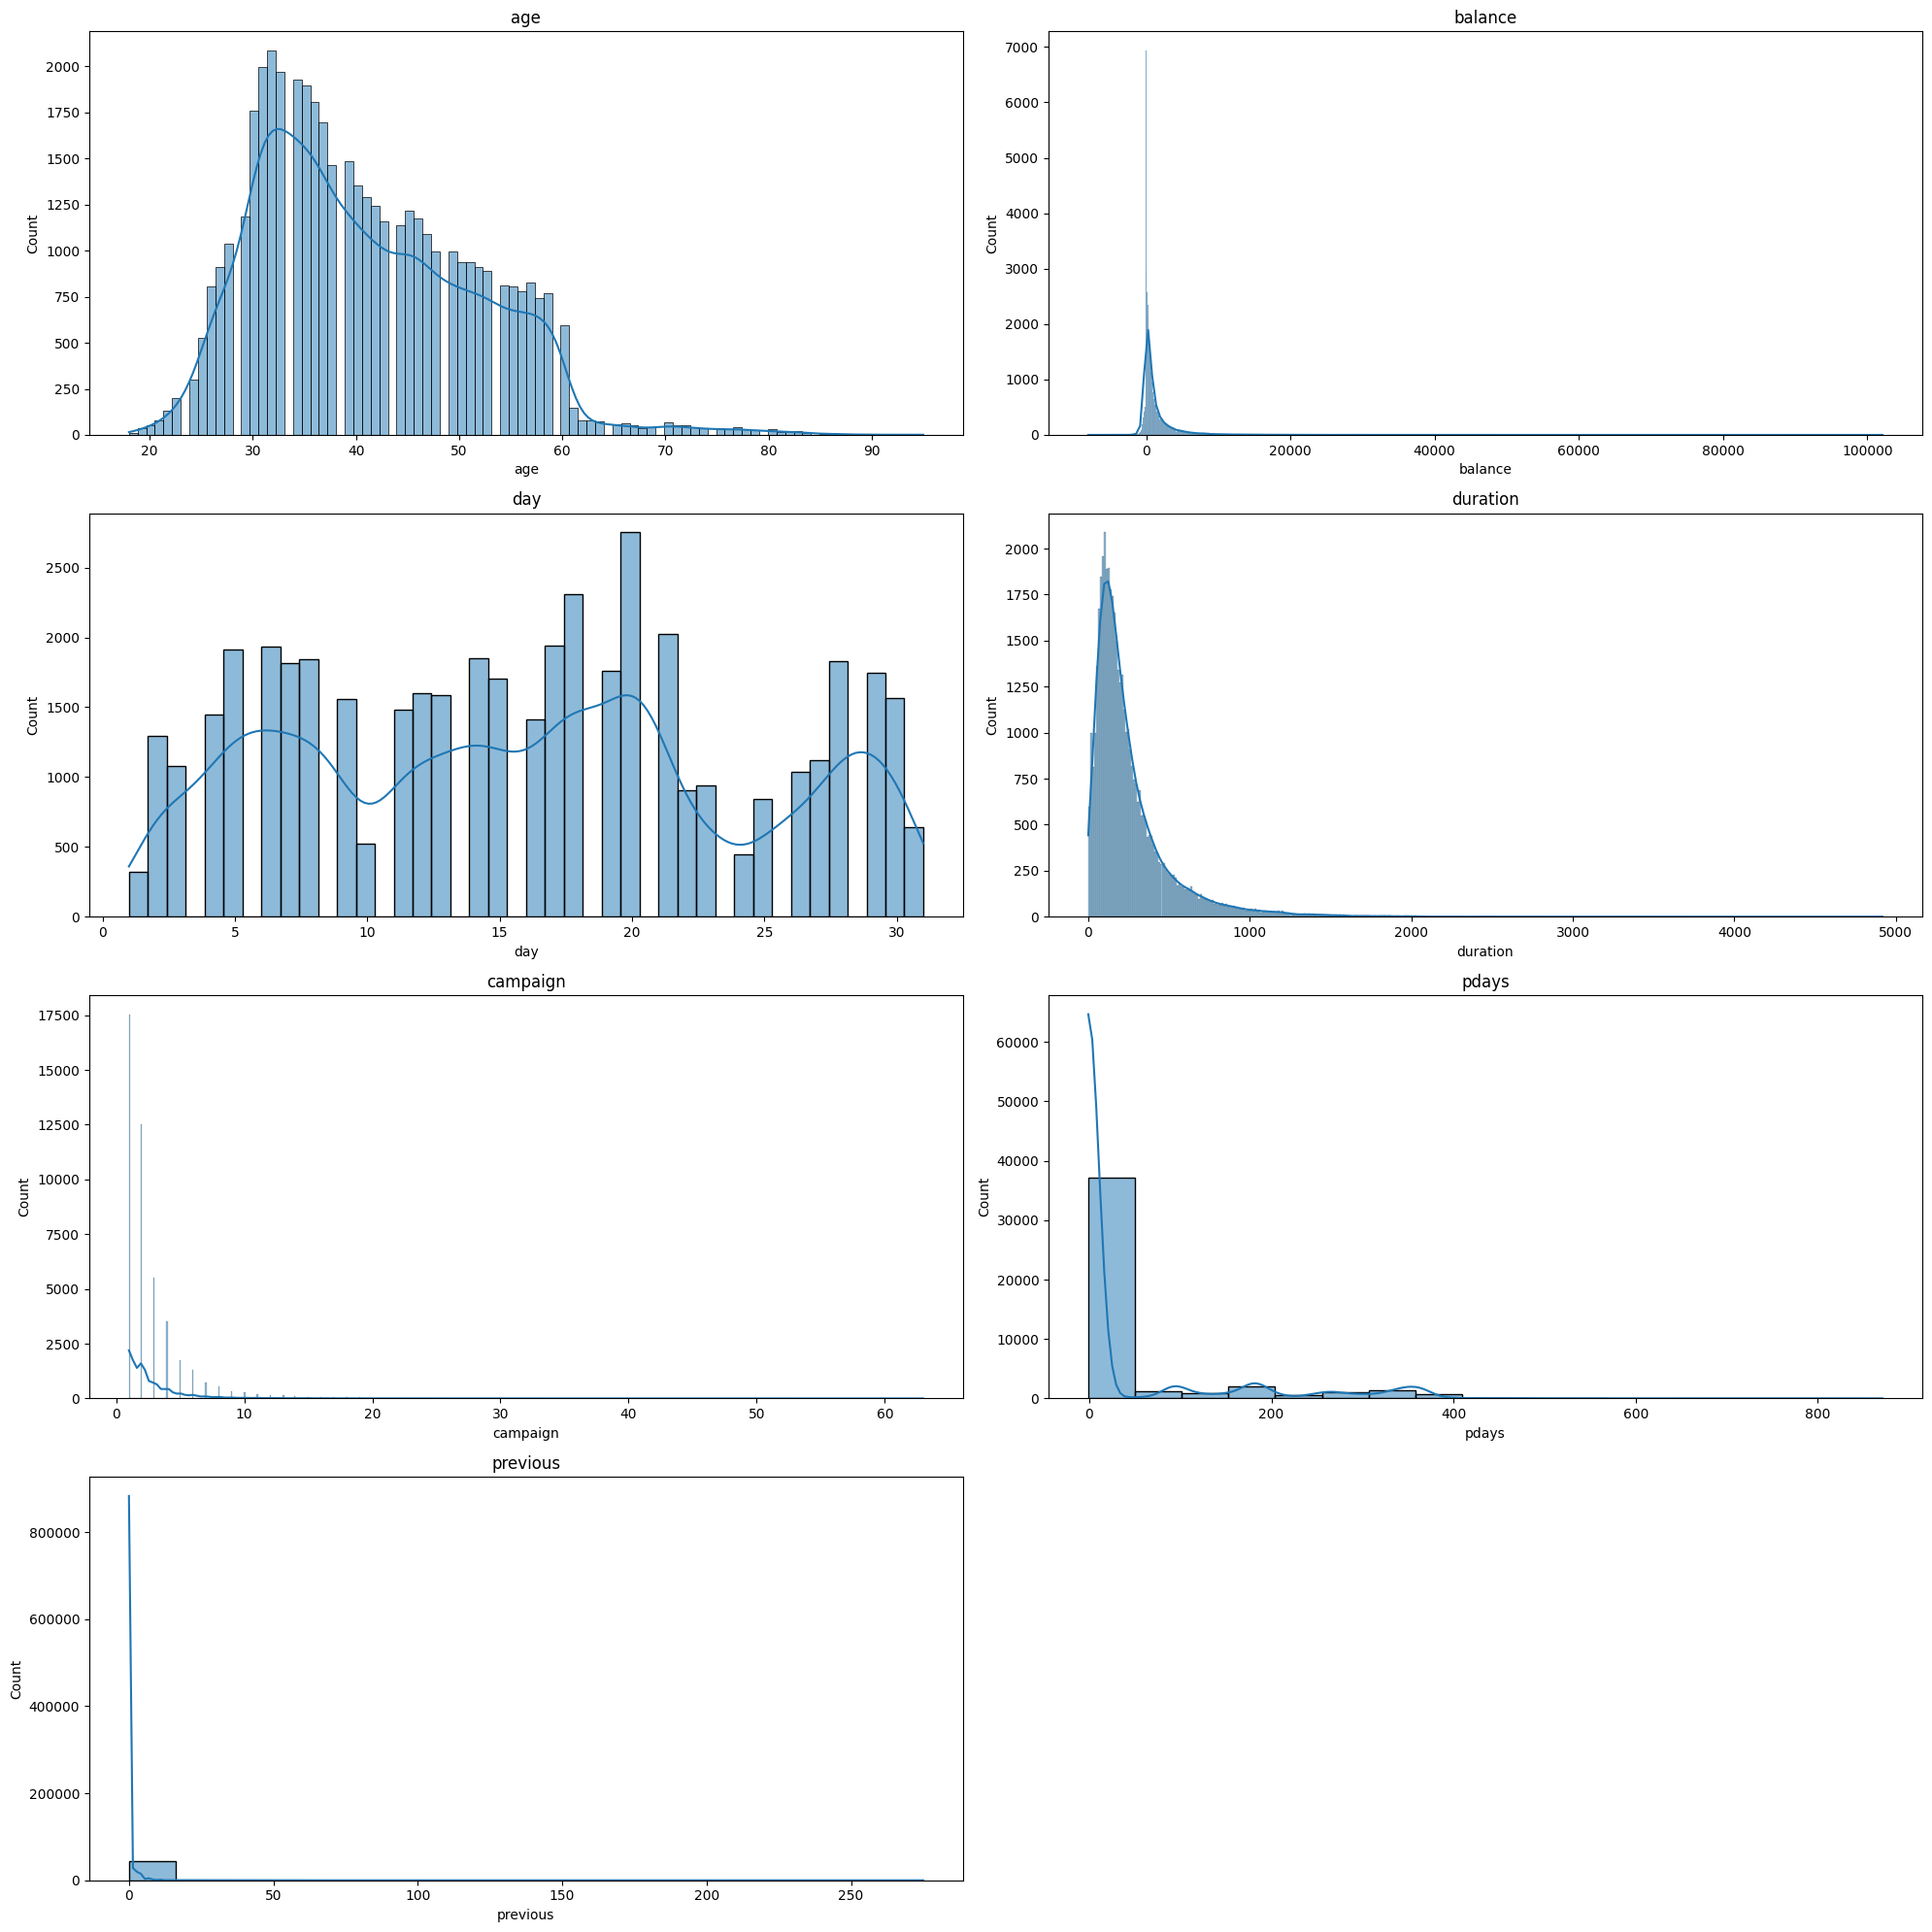

In [ ]:
plt.figure(figsize = (20,20))
for i,col in enumerate(num_cols):
  plt.subplot(4,2,i+1)
  sns.histplot(df_bank[col].dropna(),kde = True)
  plt.title(col)
plt.tight_layout()

# INFERENCE
#-----------
# All have skewed distribution

##Correlation

In [ ]:
# Creating correlation matrix
corr_mat = df_bank[num_cols].corr()
corr_mat

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

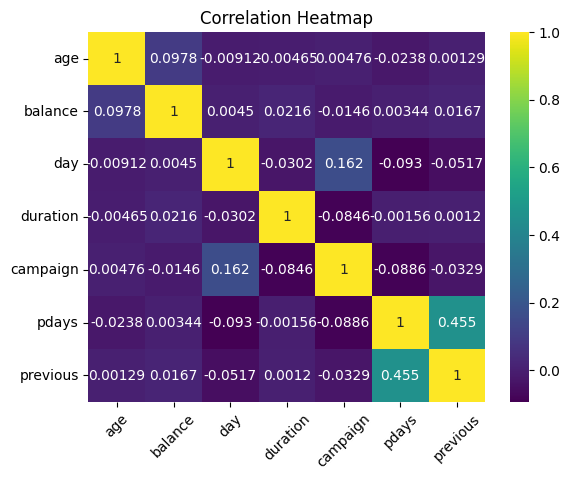

In [ ]:
# plotting heatmap to visualize correlation matrix
sns.heatmap(corr_mat, annot = True, cmap = 'viridis', fmt ='.3g' )
plt.xticks(rotation = 45)
plt.title('Correlation Heatmap')

#Preprocessing

## Data Cleaning

###Missing Value Handling

In [ ]:
##there are no missing value so no need to handle anything in this dataset

###Drop Unnecessary Columns

In [ ]:
#dropping the column 'duration' since the duration is not known before a call is performed.
# Also, after the end of the call y is obviously known.

#dropping the column 'default' since the data is highly imbalanced
# dropping the column 'day' since day of month is unlikely to have any effect on the target variable
df_bank.drop(columns = ['duration', 'default', 'day'], inplace = True)
df_bank.head()

,age,job,marital,education,balance,housing,loan,contact,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,no,unknown,may,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,no,unknown,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,yes,unknown,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,no,unknown,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,no,unknown,may,1,-1,0,unknown,no


In [ ]:
num_cols = df_bank.select_dtypes(include =['int64' , 'float64']).columns


###Outlier analysis

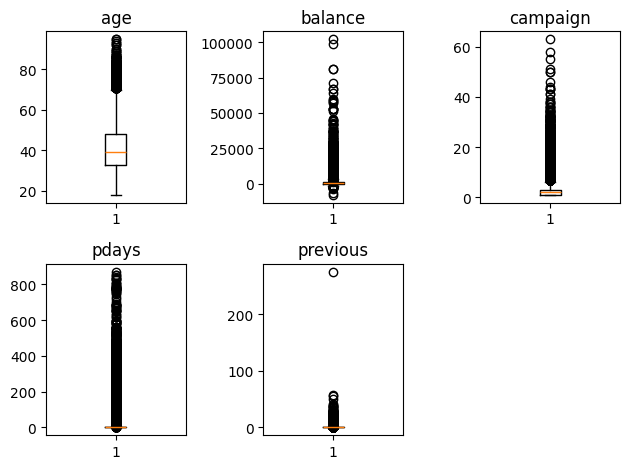

In [ ]:
#plotting boxplot to visualize the outlier
for i,col in enumerate(num_cols):
  plt.subplot(2,3,i+1)
  plt.boxplot(df_bank[col])
  plt.title(col)
plt.tight_layout()
plt.show()

###Outlier handling

In [ ]:
for col in num_cols:
  Q1 = df_bank[col].quantile(0.25)
  Q3 = df_bank[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  print('Q1 :',Q1,'\n','Q3 :',Q3,'\n','IQR :',IQR,'\n','lower_bound :', lower_bound,'\n','upper_bound :',upper_bound)
  outliers = ((df_bank[col] < lower_bound) | (df_bank[col] > upper_bound))
  #before clipping

  print(f"Column '{col}': {outliers.sum()}")

Q1 : 33.0 
 Q3 : 48.0 
 IQR : 15.0 
 lower_bound : 10.5 
 upper_bound : 70.5
Column 'age': 487
Q1 : 72.0 
 Q3 : 1428.0 
 IQR : 1356.0 
 lower_bound : -1962.0 
 upper_bound : 3462.0
Column 'balance': 4729
Q1 : 1.0 
 Q3 : 3.0 
 IQR : 2.0 
 lower_bound : -2.0 
 upper_bound : 6.0
Column 'campaign': 3064
Q1 : -1.0 
 Q3 : -1.0 
 IQR : 0.0 
 lower_bound : -1.0 
 upper_bound : -1.0
Column 'pdays': 8257
Q1 : 0.0 
 Q3 : 0.0 
 IQR : 0.0 
 lower_bound : 0.0 
 upper_bound : 0.0
Column 'previous': 8257


In [ ]:
#after clipping
for col in num_cols:
    df_bank[col] = df_bank[col].clip(lower_bound, upper_bound)

    # After clipping, verify if any outliers remain
    outliers = ((df_bank[col] < lower_bound) | (df_bank[col] > upper_bound))
    print(f"Column '{col}': {outliers.sum()}")

Column 'age': 0
Column 'balance': 0
Column 'campaign': 0
Column 'pdays': 0
Column 'previous': 0


###Duplicates handling

In [ ]:
# before duplicate removal
df_bank.duplicated().sum()

np.int64(36466)

In [ ]:
df_bank.drop_duplicates(inplace = True)

In [ ]:
# after duplicate removal
df_bank.duplicated().sum()

np.int64(0)

## Data Transformation

###Encoding

In [ ]:
# dataframe before encoding
df_bank.head()

,age,job,marital,education,balance,housing,loan,contact,month,campaign,pdays,previous,poutcome,y
0,0,management,married,tertiary,0,yes,no,unknown,may,0,0,0,unknown,no
1,0,technician,single,secondary,0,yes,no,unknown,may,0,0,0,unknown,no
2,0,entrepreneur,married,secondary,0,yes,yes,unknown,may,0,0,0,unknown,no
3,0,blue-collar,married,unknown,0,yes,no,unknown,may,0,0,0,unknown,no
4,0,unknown,single,unknown,0,no,no,unknown,may,0,0,0,unknown,no


In [ ]:
# Encoding is done on non numeric columns
print(f'categorical columns:{cat_cols}')

categorical columns:Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [ ]:
# Here  column 'y' is the target  so label ecoding is used
# Also 'housing','loan' have binary output yes and no , therefore label encoding is used

In [ ]:
label_enc = LabelEncoder()
label_cols = ['housing', 'loan', 'y']
for col in label_cols:
    df_bank[col] = label_enc.fit_transform(df_bank[col])


In [ ]:
# For the rest of the  categorical columns we use one hot encoding because these categories have no order
# Columns to be One-hot encoded
one_hot_cols = ['job', 'marital', 'education','contact', 'month', 'poutcome']

# Create encoder
encoder = OneHotEncoder(sparse_output=False)

# Encode the selected columns
encoded_data = encoder.fit_transform(df_bank[one_hot_cols])

# Create a DataFrame with encoded columns
encoded_df = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out(one_hot_cols), index = df_bank.index)

# Remove original categorical columns
df_bank = df_bank.drop(columns=one_hot_cols)
# concat encoded columns to original dataframe
df_bank = pd.concat([df_bank, encoded_df], axis=1)

In [ ]:
# Dataframe after encoding
df_bank.head()

,age,balance,housing,loan,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0,0,1,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,1,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,1,1,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0,1,0,0,0,0,0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


###Mutual information

In [ ]:
# Our target column is 'y'.
# Since 'y' is a binary target variable, we use mutual_info_classif().
# Separate the dataset into features (X) and target (y).
X = df_bank.drop('y', axis=1)
y = df_bank['y']

# To seperate  discrete
discrete_features = [
    col not in ['age', 'balance', 'campaign', 'pdays', 'previous']
    for col in X.columns
]
# Mutual information of each column in 'X' w.r.t 'y'
mi = mutual_info_classif(X,y,discrete_features = discrete_features, random_state = 42)

#converting mi values into a dataframe to understand better
mi_df = pd.DataFrame({'Features': X.columns, 'mutual Information':mi})

# Display mi
mi_df

# Based on the Mutual Information scores, no features are removed.

,Features,mutual Information
0,age,0.002140
1,balance,0.000000
2,housing,0.004739
3,loan,0.011008
4,campaign,0.009782
5,pdays,0.000000
6,previous,0.000000
7,job_admin.,0.000044
8,job_blue-collar,0.000050
9,job_entrepreneur,0.001463


###Data splitting

In [ ]:
#splitting into target and features
y = df_bank['y']
X = df_bank.drop('y', axis = 1)

#splitting into train-test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)


###Scaling

In [ ]:
# Dataframe before scaling
df_bank.head()

,age,balance,housing,loan,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0,0,1,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,1,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,1,1,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0,1,0,0,0,0,0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Scale only continuos numeric values
print(num_cols)

scaler = MinMaxScaler()
df_bank[num_cols] = scaler.fit_transform(df_bank[num_cols])

Index(['age', 'balance', 'campaign', 'pdays', 'previous'], dtype='object')


In [ ]:
# Dataframe after scaling
df_bank.head()

,age,balance,housing,loan,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0.0,0.0,1,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1,1,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1,0,0.0,0.0,0.0,0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#Model Building

##Models

### SVM

In [ ]:
#building the model object
SVM_obj = SVC()
#training the model
SVM_obj.fit(X_train, y_train)
# predictions using the model
y_pred_SVM = SVM_obj.predict(X_test)

# evaluate the model performance
acc_SVM = accuracy_score(y_test, y_pred_SVM)
precision_score_SVM = precision_score(y_test, y_pred_SVM)
recall_score_SVM = recall_score(y_test, y_pred_SVM)
f1_score_SVM = f1_score(y_test, y_pred_SVM)


print("SVM Accuracy:", acc_SVM)
print("SVM Precision:", precision_score_SVM)
print("SVM Recall:", recall_score_SVM)
print("SVM F1 Score:", f1_score_SVM)



SVM Accuracy: 0.7129788450543167
SVM Precision: 0.6407185628742516
SVM Recall: 0.19489981785063754
SVM F1 Score: 0.2988826815642458


### Naive Bayes

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
precision_score_nb = precision_score(y_test, y_pred_nb)
recall_score_nb = recall_score(y_test, y_pred_nb)
f1_score_nb = f1_score(y_test, y_pred_nb)

print('Accuracy of Naive Bayes',acc_nb)
print('Precision of Naive Bayes',precision_score_nb)
print('Recall of Naive Bayes',recall_score_nb)
print('F1 score of Naive Bayes',f1_score_nb)


Accuracy of Naive Bayes 0.6746712407089765
Precision of Naive Bayes 0.4781659388646288
Recall of Naive Bayes 0.3989071038251366
F1 score of Naive Bayes 0.43495531281032773


###Decision Tree Model Building

In [ ]:
# building model object
dT_model = DecisionTreeClassifier()

# Training the model
dT_model.fit(X_train, y_train)

# Predicting using the model
y_pred_dT = dT_model.predict(X_test)

# Evaluate model performance
acc_dT = accuracy_score(y_test, y_pred_dT)
precision_score_dT = precision_score(y_test, y_pred_dT)
recall_score_dT = recall_score(y_test, y_pred_dT)
f1_score_dT = f1_score(y_test, y_pred_dT)



print('Accuracy of Decision Tree model',acc_dT)
print('Precision of Decision Tree model',precision_score_dT)
print('Recall of Decision Tree model',recall_score_dT)
print('F1 score of Decision Tree model',f1_score_dT)



In [ ]:
# Cross validation

# StratifiedKFold

# Since dataset is imbalanced , we have to use StratifiedKFold
# Since datset is imbalanced ,  we can't relay on accuracy alone
skf_obj = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 27)
scores = cross_val_score(DecisionTreeClassifier() , X_train ,y_train , cv = skf_obj, scoring ='f1')
print("For Decision Tree model")
print('StratifiedKFold cross validation scores : ', scores)
print('Mean of cv scores : ', scores.mean())
print("\n\n\n")


# GridSearchCV

# Since datset is imbalanced ,  we can't relay on accuracy alone
para_grid = {'criterion' : ['gini','entropy'], 'max_depth' : [2,3,4,5,6,8,10] , 'min_samples_split': [2,4,6,8]}

grid = GridSearchCV(DecisionTreeClassifier(random_state = 42), para_grid , cv = 5, scoring = 'f1')
grid.fit(X_train,y_train)
print("For Decision Tree model")
print("Best parameters : ",grid.best_params_)
print("Best cross validation score : ",grid.best_score_)

# we build the model using the best parameters identified
best_dT_grid = grid.best_estimator_
# Train the model
best_dT_grid.fit(X_train,y_train)
# make prediction using the model
y_pred_dT_grid = best_dT_grid.predict(X_test)
# evaluate the model performance
print("Accuracy :", accuracy_score(y_test, y_pred_dT_grid))
print("Precision :", precision_score(y_test, y_pred_dT_grid))
print("Recall :", recall_score(y_test, y_pred_dT_grid))
print("F1 Score :", f1_score(y_test, y_pred_dT_grid))
print("\n\n\n")



# Random search CV

# Since datset is imbalanced ,  we can't relay on accuracy alone
grid_random = RandomizedSearchCV(DecisionTreeClassifier(random_state = 42),  param_distributions = para_grid , cv = 5, scoring = 'f1')
grid_random.fit(X_train,y_train)
print("For Decision Tree model")
print("Best parameters : ",grid_random.best_params_)
print("Best cross validation score : ",grid_random.best_score_)

# we build the model using the best parameters identified
best_dT_random = grid_random.best_estimator_
# Train the model
best_dT_random.fit(X_train,y_train)
# make prediction using the model
y_pred_dT_random = best_dT_random.predict(X_test)
# evaluate the model performance
print("Accuracy :", accuracy_score(y_test, y_pred_dT_random))
print("Precision :", precision_score(y_test, y_pred_dT_random))
print("Recall :", recall_score(y_test, y_pred_dT_random))
print("F1 Score :", f1_score(y_test, y_pred_dT_random))
print("\n\n\n")


### Random Forest Model Building

In [ ]:
# building model object
rf_model = RandomForestClassifier()

# Training the model
rf_model.fit(X_train, y_train)

# Predicting using the model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model performance
acc_rf = accuracy_score(y_test, y_pred_rf)
precision_score_rf = precision_score(y_test, y_pred_rf)
recall_score_rf = recall_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf)



print('Accuracy of Random Forest model',acc_rf)
print('Precision of Random Forest model',precision_score_rf)
print('Recall of Random Forest model',recall_score_rf)
print('F1 score of Random Forest model',f1_score_rf)



In [ ]:
# Cross validation

# StratifiedKFold

# Since dataset is imbalanced , we have to use StratifiedKFold
# Since datset is imbalanced ,  we can't rely on accuracy alone
skf_obj = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 27)
scores = cross_val_score(RandomForestClassifier() , X_train ,y_train , cv = skf_obj, scoring ='f1')
print("For Random Forest model")
print('StratifiedKFold cross validation scores : ', scores)
print('Mean of cv scores : ', scores.mean())
print("\n\n\n")


# GridSearchCV

# Since datset is imbalanced ,  we can't relay on accuracy alone
para_grid = {'n_estimators' : [50, 100, 200] , 'criterion' : ['gini','entropy'], 'max_depth' : [5, 10, 20] , 'min_samples_split': [2, 5, 10]}

grid = GridSearchCV(RandomForestClassifier(random_state = 42), para_grid , cv = skf_obj, scoring = 'f1')
grid.fit(X_train,y_train)
print("For Random Forest model")
print("Best parameters : ",grid.best_params_)
print("Best cross validation score : ",grid.best_score_)

# we build the model using the best parameters identified
best_rf_grid = grid.best_estimator_
# Train the model
best_rf_grid.fit(X_train,y_train)
# make prediction using the model
y_pred_rf_grid = best_rf_grid.predict(X_test)
# evaluate the model performance
print("Accuracy :", accuracy_score(y_test, y_pred_rf_grid))
print("Precision :", precision_score(y_test, y_pred_rf_grid))
print("Recall :", recall_score(y_test, y_pred_rf_grid))
print("F1 Score :", f1_score(y_test, y_pred_rf_grid))
print("\n\n\n")



# Random search CV

# Since datset is imbalanced ,  we can't relay on accuracy alone
grid_random = RandomizedSearchCV(RandomForestClassifier(random_state = 42),  param_distributions = para_grid , cv = skf_obj, scoring = 'f1', n_iter = 10)
grid_random.fit(X_train,y_train)
print("For Random Forest model")
print("Best parameters : ",grid_random.best_params_)
print("Best cross validation score : ",grid_random.best_score_)

# we build the model using the best parameters identified
best_rf_random = grid_random.best_estimator_
# Train the model
best_rf_random.fit(X_train,y_train)
# make prediction using the model
y_pred_rf_random = best_rf_random.predict(X_test)
# evaluate the model performance
print("Accuracy :", accuracy_score(y_test, y_pred_rf_random))
print("Precision :", precision_score(y_test, y_pred_rf_random))
print("Recall :", recall_score(y_test, y_pred_rf_random))
print("F1 Score :", f1_score(y_test, y_pred_rf_random))
print("\n\n\n")
